# Семинар №4: Компьютерное зрение на базе YOLOv8/v11

В рамках данного семинара мы пройдем путь от простого запуска предобученной модели до создания прототипа системы видеоаналитики.

### План занятия:
1. **Инференс**: Детекция и Сегментация.
2. **Data Extraction**: Работа с объектами `Results`, извлечение координат и масок.
3. **Object Tracking**: Использование встроенных трекеров (ByteTrack/BoTSORT).
4. **Прикладная задача**: Реализация логики пересечения линии и построение тепловых карт.

# Установка библиотек

In [ ]:
!pip install ultralytics opencv-python matplotlib numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00


# Импорт библиотек

In [ ]:
from ultralytics import YOLO
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial import distance
import time

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Загрузка моделей

- YOLO detection
- YOLO segmentation

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

detector = YOLO('yolov8s.pt').to(device)
segmenter = YOLO('yolov8n-seg.pt').to(device)

Using device: cuda


# Детекция объектов


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 40.3ms
Speed: 4.1ms preprocess, 40.3ms inference, 12.8ms postprocess per image at shape (1, 3, 640, 480)


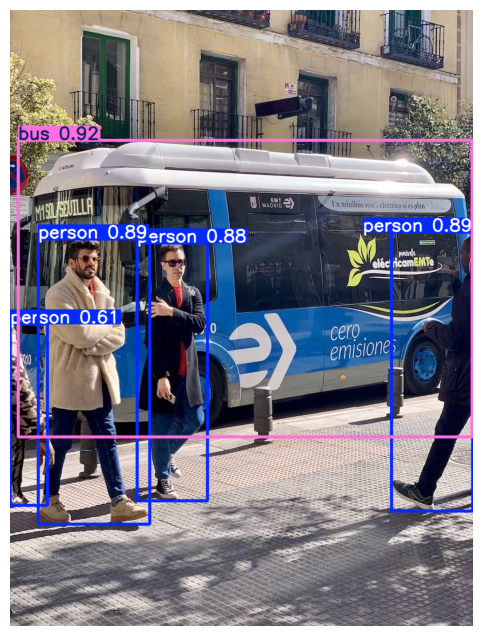

In [ ]:
# Запуск детекции на GPU
img_url = 'https://ultralytics.com/images/bus.jpg'
results = detector.predict(img_url, conf=0.25, device=device)

# Отрисовка результатов
res_plotted = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Теория: Работа с YOLO

### 1. Метод `predict()`
Основной метод для запуска инференса. Основные параметры:
- `source`: путь к фото, видео или URL.
- `conf`: порог уверенности (0.0 - 1.0). Все, что ниже, отсекается.
- `iou`: порог Non-Maximum Suppression (NMS), помогает убрать дублирующиеся рамки вокруг одного объекта.
- `classes`: список ID классов для детекции (например, `classes=[0]` только для людей).

### 2. Что такое Classes?
Модели YOLO обучаются на наборах данных (например, COCO), где каждому объекту присвоен числовой ID (class index):
- **0**: person
- **1**: bicycle
- **2**: car
- **5**: bus

Вы можете обращаться к именам классов через атрибут `model.names`.

### 3. Форматы координат
Объект `Results` возвращает боксы в нескольких форматах:
- `xyxy`: [x_min, y_min, x_max, y_max] (в пикселях).
- `xywh`: [center_x, center_y, width, height] (в пикселях).
- `xyxyn` / `xywhn`: нормализованные координаты (от 0 до 1), удобные для масштабирования.

# Сырые данные детекции

In [ ]:
# Разбор объекта Results
result = results[0]

print(f"Обнаружено объектов: {len(result.boxes)}")

# Итерируемся по боксам
for box in result.boxes:
    coords = box.xyxy[0].tolist() # [x1, y1, x2, y2]
    confidence = box.conf[0].item()
    cls_id = int(box.cls[0].item())
    cls_name = detector.names[cls_id]

    print(f"Класс: {cls_name:10} | Уверенность: {confidence:.2f} | Координаты: {[round(c,1) for c in coords]}")

Обнаружено объектов: 5
Класс: bus        | Уверенность: 0.92 | Координаты: [15.0, 228.5, 808.2, 748.1]
Класс: person     | Уверенность: 0.89 | Координаты: [667.3, 389.6, 809.7, 878.5]
Класс: person     | Уверенность: 0.89 | Координаты: [49.9, 401.8, 244.5, 901.8]
Класс: person     | Уверенность: 0.88 | Координаты: [222.1, 408.2, 345.5, 860.7]
Класс: person     | Уверенность: 0.61 | Координаты: [0.2, 550.8, 65.2, 869.0]


# YOLO Segmentation


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 265.9ms
Speed: 3.7ms preprocess, 265.9ms inference, 15.7ms postprocess per image at shape (1, 3, 640, 480)


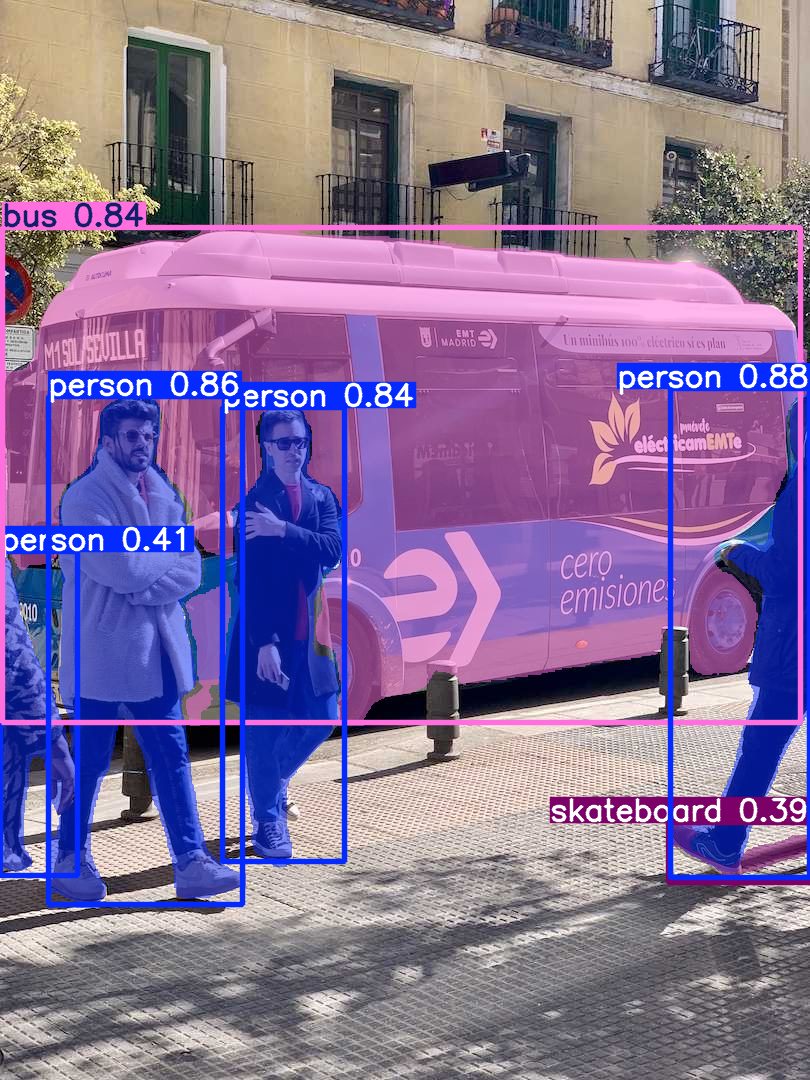

In [ ]:
seg = segmenter('https://ultralytics.com/images/bus.jpg')
seg[0].show()

# Получение сегментационных масок

Объект `results.masks` содержит бинарные маски для каждого обнаруженного объекта.

In [ ]:
masks = seg[0].masks

if masks is not None:
    print(f'Обнаружено масок: {len(masks.data)}')
    # Каждая маска — это тензор (H, W)
    # data[0] — маска первого объекта
    first_mask = masks.data[0].cpu().numpy()
    print(f'Размер маски: {first_mask.shape}')
else:
    print('Маски не найдены')

Обнаружено масок: 6
Размер маски: (640, 480)


### Визуализация отдельных масок

Ниже приведен код для циклического отображения каждой найденной маски. Это полезно для понимания того, как модель изолирует объекты.

WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.


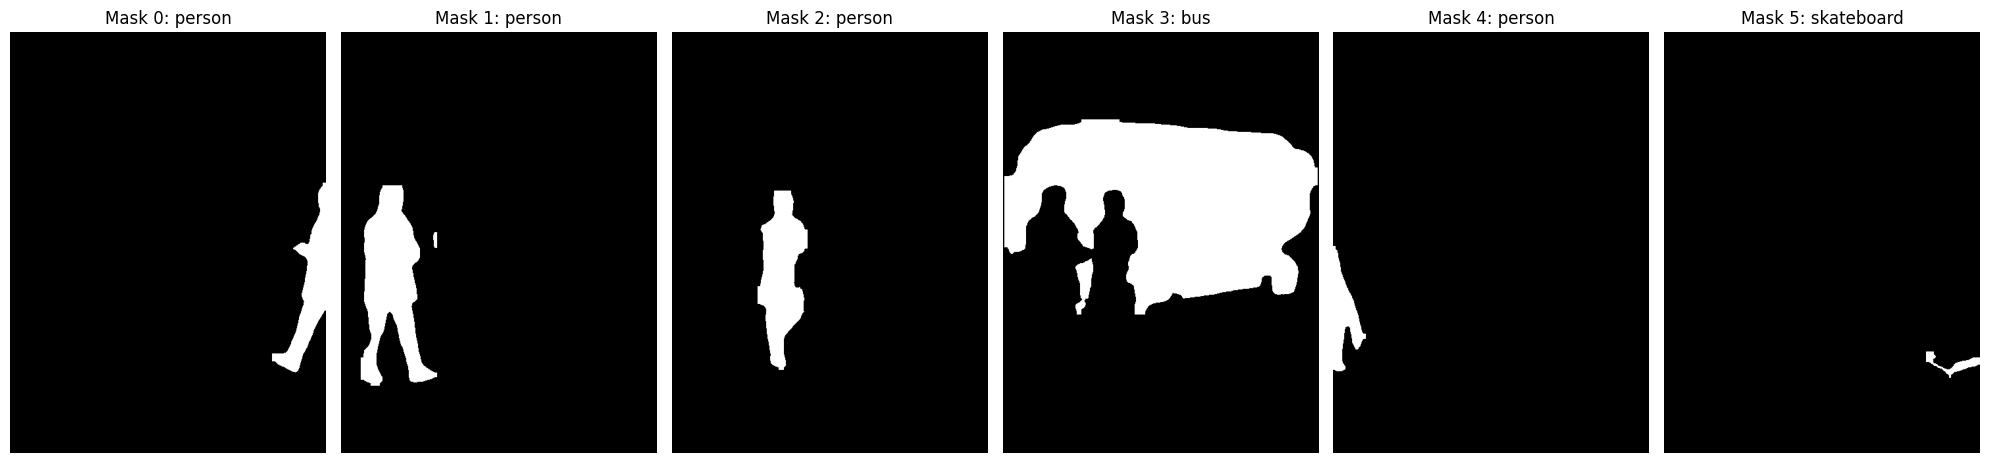

In [ ]:
if seg[0].masks is not None:
    masks = seg[0].masks.data.cpu().numpy()
    names = seg[0].names
    classes = seg[0].boxes.cls.cpu().numpy()

    num_masks = len(masks)
    fig, axes = plt.subplots(1, num_masks, figsize=(20, 5))

    if num_masks == 1: axes = [axes]

    for i, mask in enumerate(masks):
        axes[i].imshow(mask, cmap='gray')
        cls_name = names[int(classes[i])]
        axes[i].set_title(f"Mask {i}: {cls_name}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Маски не найдены для визуализации.")

# Object Tracking на видео

Трекинг наиболее эффективен при работе с видеопотоком. Мы будем использовать встроенный метод `.track()`, который поддерживает сохранение состояний объектов (параметр `persist=True`).

In [ ]:
from google.colab import files
import os

print("Выберите видеофайл для загрузки:")
uploaded = files.upload()

if uploaded:
    video_path = list(uploaded.keys())[0]
    print(f"Файл {video_path} успешно загружен и готов к обработке.")
else:
    print("Файл не был выбран. Будет использовано видео по умолчанию.")

Выберите видеофайл для загрузки:


WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camer

In [ ]:
# 1. Подготовка видео (используем загруженное или скачиваем по умолчанию)
import os
import urllib.request

def prepare_video():
    # Если файл уже загружен через виджет, используем его
    if 'video_path' in globals() and os.path.exists(video_path):
        print(f"Используем загруженный файл: {video_path}")
        return video_path


current_video = prepare_video()

In [ ]:
import cv2
import os

if 'current_video' in globals() and os.path.exists(current_video):
    cap = cv2.VideoCapture(current_video)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    output_path = 'full_processed_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print(f"Начинаю полную обработку видео: {total_frames} кадров...")

    # Запуск трекера в режиме стриминга на все кадры
    results = detector.track(source=current_video, stream=True, persist=True, device=device, verbose=False)

    for i, res in enumerate(results):
        annotated_frame = res.plot()
        out.write(annotated_frame)

        if i % 100 == 0:
            print(f"Обработано кадров: {i}/{total_frames}")

    cap.release()
    out.release()
    print(f"Готово! Видео сохранено как: {output_path}")

    # Конвертация видео в веб-совместимый формат
    web_compatible_output_path = 'web_compatible_video.mp4'
    print(f"Конвертирую видео в веб-совместимый формат: {web_compatible_output_path}...")
    os.system(f"ffmpeg -y -i {output_path} -c:v libx264 -preset veryfast -crf 23 -movflags faststart -pix_fmt yuv420p {web_compatible_output_path}")
    print(f"Веб-совместимое видео сохранено как: {web_compatible_output_path}")

else:
    print("Видео файл не найден.")

TypeError: stat: path should be string, bytes, os.PathLike or integer, not NoneType

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_file = 'web_compatible_video.mp4' # Changed to display the web-compatible video

if os.path.exists(video_file):
    mp4 = open(video_file, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    display(HTML(f"""
    <video width=800 controls>
          <source src=\"{data_url}\" type=\"video/mp4\">
    </video>
    """))
else:
    print("Файл не найден. Убедитесь, что обработка завершена.")

Файл не найден. Убедитесь, что обработка завершена.


In [ ]:
import cv2
import os
from IPython.display import HTML
from base64 import b64encode

# Ensure current_video is defined and exists
if 'current_video' in globals() and os.path.exists(current_video):
    cap = cv2.VideoCapture(current_video)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    output_path_detection_only = 'detection_only_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_detection_only = cv2.VideoWriter(output_path_detection_only, fourcc, fps, (width, height))

    print(f"Начинаю обработку видео для детекции без трекинга: {total_frames} кадров...")

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Perform detection (not tracking)
        # Using detector.predict instead of detector.track
        results_det = detector.predict(source=frame, conf=0.1, iou=0.95, device=device, verbose=False)
        annotated_frame_det = results_det[0].plot()
        out_detection_only.write(annotated_frame_det)

        frame_count += 1
        if frame_count % 100 == 0:
            print(f"Обработано кадров для детекции: {frame_count}/{total_frames}")

    cap.release()
    out_detection_only.release()
    print(f"Готово! Видео с детекцией сохранено как: {output_path_detection_only}")

    # Convert to web-compatible format for display
    web_compatible_output_path_det = 'web_compatible_detection_video.mp4'
    print(f"Конвертирую видео детекции в веб-совместимый формат: {web_compatible_output_path_det}...")
    os.system(f"ffmpeg -y -i {output_path_detection_only} -c:v libx264 -preset veryfast -crf 23 -movflags faststart -pix_fmt yuv420p {web_compatible_output_path_det}")
    print(f"Веб-совместимое видео детекции сохранено как: {web_compatible_output_path_det}")

    # Display the web-compatible video
    if os.path.exists(web_compatible_output_path_det):
        mp4_det = open(web_compatible_output_path_det, 'rb').read()
        data_url_det = "data:video/mp4;base64," + b64encode(mp4_det).decode()

        display(HTML(f"""
        <video width=800 controls>
              <source src=\"{data_url_det}\" type=\"video/mp4\">
        </video>
        """))
    else:
        print("Веб-совместимый файл видео детекции не найден.")
else:
    print("Видео файл не найден для обработки. Пожалуйста, убедитесь, что 'current_video' указывает на существующий файл.")

TypeError: stat: path should be string, bytes, os.PathLike or integer, not NoneType

# Heatmap активности

Для наглядности мы используем Гауссово размытие, чтобы превратить отдельные точки в плотную карту интенсивности.

In [ ]:
def get_center(box):
    x1,y1,x2,y2 = box
    return np.array([(x1+x2)/2,(y1+y2)/2])

In [ ]:
import scipy.ndimage
import cv2
import numpy as np
import matplotlib.pyplot as plt

if 'current_video' in globals() and os.path.exists(current_video):
    cap = cv2.VideoCapture(current_video)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Create an empty heatmap with video dimensions
    heatmap = np.zeros((height, width))
    all_person_centers = []
    people_class = 0 # Assuming 'person' class ID is 0

    print(f"Collecting data for heatmap from video: {current_video}...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Perform detection on the current frame
        results_frame = detector.predict(source=frame, conf=0.25, device=device, verbose=False)
        boxes_frame = results_frame[0].boxes.xyxy.cpu().numpy()
        classes_frame = results_frame[0].boxes.cls.cpu().numpy()

        # Filter for 'person' class and collect centers
        for i, cls_id in enumerate(classes_frame):
            if int(cls_id) == people_class:
                box = boxes_frame[i]
                cx, cy = get_center(box)
                # Ensure coordinates are within heatmap boundaries
                if 0 <= int(cy) < height and 0 <= int(cx) < width:
                    all_person_centers.append((int(cx), int(cy)))

    cap.release()
    print(f"Collected {len(all_person_centers)} person detections across all frames.")

    # Populate the heatmap with collected centers
    for cx, cy in all_person_centers:
        heatmap[cy, cx] += 1

    # Apply Gaussian smoothing
    smoothed_heatmap = scipy.ndimage.gaussian_filter(heatmap, sigma=20) # Adjusted sigma for potentially lower resolution video

    plt.figure(figsize=(10, 6))
    plt.imshow(smoothed_heatmap, cmap='jet', alpha=0.7) # Use alpha to see background if any
    plt.title('Activity Heatmap from Video')
    plt.colorbar(label='Activity Level')
    plt.axis('off')
    plt.show()
else:
    print("Видео файл не найден для построения тепловой карты. Пожалуйста, убедитесь, что 'current_video' указывает на существующий файл.")

TypeError: stat: path should be string, bytes, os.PathLike or integer, not NoneType

# Измерение времени инференса

In [ ]:
start = time.time()
detector('https://ultralytics.com/images/bus.jpg')
print('Inference time:', time.time()-start)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 13.0ms
Speed: 3.4ms preprocess, 13.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)
Inference time: 0.05611562728881836


Самостоятельное задание

# Мини-проект: Умная камера наблюдения

Реализуйте мини-систему видеонаблюдения, которая выполняет:

1. Детекцию людей
2. Трекинг людей
3. Подсчёт количества людей
4. Оценку плотности людей
5. Построение heatmap активности

## Требования

Система должна:

- принимать видеопоток
- детектировать людей
- отслеживать их перемещение
- считать вход/выход через линию
- строить карту активности

## Дополнительные улучшения

Можно реализовать:

- сигнал тревоги при высокой плотности людей
- детекцию оставленных объектов
- определение направления движения
- оценку скорости движения людей

## Итог

Результатом работы должен стать скрипт,
выполняющий анализ видеопотока в реальном времени.